### Coupling GIPL and ECSimpleSnow models

Before you begin, install:

```conda install -c conda-forge pymt pymt_gipl pymt_ecsimplesnow seaborn```

In [13]:

import sys
import os

# Add the parent directory to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from src.bmi_compose import compose
import pymt.models

sns.set(style="whitegrid", font_scale=1.2)

#### Load ECSimpleSnow module from PyMT

In [15]:
ec = pymt.models.ECSimpleSnow()
print(ec.name)

# List input and output variable names.
print(ec.output_var_names)
print(ec.input_var_names)

The 1D Snow Model
('snowpack__depth', 'snowpack__mass-per-volume_density')
('precipitation_mass_flux', 'land_surface_air__temperature', 'precipitation_mass_flux_adjust_factor', 'snow_class', 'open_area_or_not', 'snowpack__initial_depth', 'snowpack__initial_mass-per-volume_density')


#### Load GIPL module from PyMT

In [16]:
gipl = pymt.models.GIPL()
print(gipl.name)

# List input and output variable names.
print(gipl.output_var_names)
print(gipl.input_var_names)




The 1D GIPL Model
('soil__temperature', 'model_soil_layer__count')
('land_surface_air__temperature', 'snowpack__depth', 'snow__thermal_conductivity', 'soil_water__volume_fraction', 'soil_unfrozen_water__a', 'soil_unfrozen_water__b')


Call the setup method on both ECSimpleSnow and GIPL to get default configuration files and data.

In [17]:

units  = {"snowpack__depth" : "m"}
x = lambda rsn : rsn * rsn * 2.846

conv = [({"snowpack__mass-per-volume_density" : "g cm-3"}, "snow__thermal_conductivity", x)]

gipl_compose = compose(ec, gipl, unitsDict = units, conversions = conv)

defaults = gipl_compose.setup(".")



In [18]:
gipl_compose.initialize(defaults)


 *** Warning: No available path, will try to find inputs
 from the same folder of this configuration :
 ./                                                              
 *** Warning: No available path, will try to find inputs
 from the same folder of this configuration :
 ./                                                                                                                                                                  
 *** Warning: No available output path, will try to write outputs
 to the same folder of this configuration :
 ./                                                                                                                                                                  


<src.bmi_compose.compose.<locals>.ComposedBmi at 0x7f8c348fb010>

In [19]:
# Get soil depth: [unit: m]
depth = gipl.get_grid_z(2)
n_depth = int(len(depth))

/tmp/ipykernel_84456/1631582154.py:2: DeprecationWarning: Call to deprecated method get_grid_z. (use grid_z)
  depth = gipl.get_grid_z(2)


In [20]:
# Get the length of forcing data:
ntime = int(gipl.end_time)

# Define a variable to store soil temperature through the time period

tsoil = np.zeros((n_depth, ntime)) * np.nan

print("Final soil temperatures will be ", tsoil.shape)

Final soil temperatures will be  (176, 365)


[ 1.0689912e-38 -9.3019262e-06 -1.8603852e-05 -2.7905777e-05
 -3.7207701e-05 -4.6509627e-05 -5.5811550e-05 -6.5113476e-05
 -7.4415395e-05 -8.3717314e-05 -9.3019233e-05 -1.0232115e-04
 -1.1162307e-04 -1.2092498e-04 -1.3022689e-04 -1.3952881e-04
 -1.4883072e-04 -1.5813262e-04 -1.6743453e-04 -1.7673643e-04
 -1.8603832e-04 -1.9534022e-04 -2.0464211e-04 -2.1394400e-04
 -2.2324589e-04 -2.3254777e-04 -2.4184964e-04 -2.5115153e-04
 -2.6045341e-04 -2.6417413e-04 -2.6789488e-04 -2.7161563e-04
 -2.7347601e-04 -2.7533638e-04 -2.7719676e-04 -2.7812694e-04
 -2.7868504e-04 -2.7887110e-04 -2.7905713e-04 -1.6410856e-03
 -2.9453759e-03 -6.6563017e-03 -1.2615088e-02 -2.4127355e-02
 -3.5404488e-02 -4.6517219e-02 -5.7502206e-02 -8.9736067e-02
 -1.1091301e-01 -1.3185400e-01 -1.5258677e-01 -1.7313126e-01
 -1.9350255e-01 -2.1371242e-01 -2.3116341e-01 -2.4856678e-01
 -2.6594022e-01 -2.8328502e-01 -3.0060223e-01 -3.1789264e-01
 -3.3515689e-01 -3.5239550e-01 -3.7149712e-01 -3.9025953e-01
 -4.0862733e-01 -4.26620

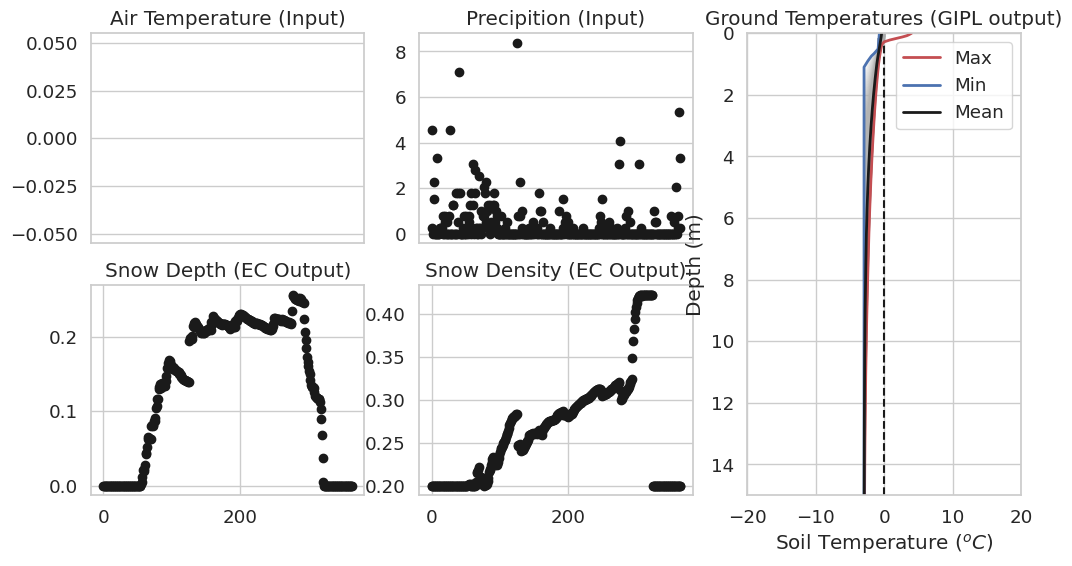

In [21]:
fig = plt.figure(figsize=[12, 6])

ax2 = fig.add_subplot(2, 3, 1)
ax2.set_title("Air Temperature (Input)")

ax3 = fig.add_subplot(2, 3, 2)
ax3.set_title("Precipition (Input)")

ax4 = fig.add_subplot(2, 3, 4)
ax4.set_title("Snow Depth (EC Output)")

ax5 = fig.add_subplot(2, 3, 5)
ax5.set_title("Snow Density (EC Output)")

ax1 = fig.add_subplot(2, 3, (3, 6))
ax1.set_ylim([15, 0])
ax1.set_xlim([-20, 20])
ax1.set_xlabel("Soil Temperature ($^oC$)")
ax1.set_ylabel("Depth (m)")
ax1.plot([0, 0], [15, 0], "k--")

for i in np.arange(365):


    tair = gipl_compose.get_value("c")

    gipl.set_value("land_surface_air__temperature", tair)

    gipl_compose.update()



    


    tsoil[:, i] = gipl_compose.get_value("soil__temperature")  # Save results to a matrix

    prec = gipl_compose.get_value("precipitation_mass_flux")
    snd = gipl_compose.get_value("snowpack__depth", units="m")
    rsn = gipl_compose.get_value("snowpack__mass-per-volume_density", units="g cm-3")



    ax1.plot(tsoil[depth >= 0, i], depth[depth >= 0], color=[0.7, 0.7, 0.7], alpha=0.1)

    ax2.scatter(i, tair, c="k")
    ax3.scatter(i, prec, c="k")
    ax4.scatter(i, snd, c="k")
    ax5.scatter(i, rsn, c="k")




ax1.plot(
    tsoil[depth >= 0, :].max(axis=1), depth[depth >= 0], "r", linewidth=2, label="Max"
)
ax1.plot(
    tsoil[depth >= 0, :].min(axis=1), depth[depth >= 0], "b", linewidth=2, label="Min"
)
ax1.plot(
    tsoil[depth >= 0, :].mean(axis=1), depth[depth >= 0], "k", linewidth=2, label="Mean"
)
ax1.legend()
ax1.set_title("Ground Temperatures (GIPL output)")

ax2.set_xticks([])
ax3.set_xticks([])

print(gipl_compose.get_value("soil__temperature"))


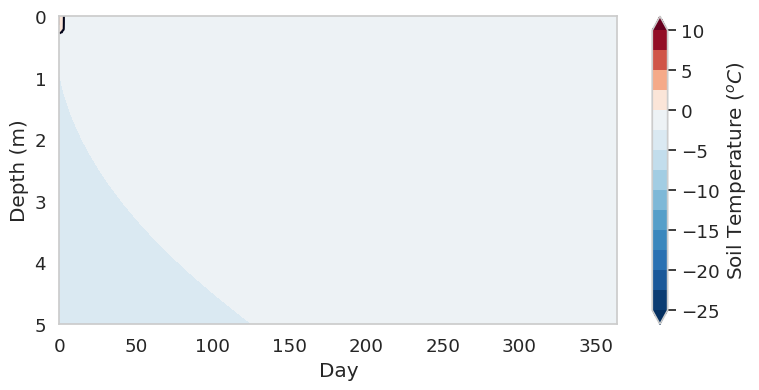

In [22]:
fig = plt.figure(figsize=[9, 4])
divnorm = mcolors.TwoSlopeNorm(vmin=-25.0, vcenter=0.0, vmax=10)
plt.contourf(
    np.arange(ntime),
    depth,
    tsoil,
    np.linspace(-25, 10, 15),
    norm=divnorm,
    cmap="RdBu_r",
    extend="both",
)

plt.ylim([5, 0])
cb = plt.colorbar()
plt.xlabel("Day")
plt.ylabel("Depth (m)")
cb.ax.set_ylabel("Soil Temperature ($^oC$)")

plt.contour(np.arange(ntime), depth, tsoil, [0])  # ZERO

